# Data Rexploration of MITRE ATT&CK and MITRE D3FEND

* Name: Logan
* CID: 81399688
* Email: ldellwong1@gmail.com

---

## 1. What is MITRE ATTACK and D3FEND?

**ATTACK & D3FEND** 

MITRE ATT&CK is a comprehensive knowledge base of adversary tactics, techniques, and procedures (TTPs) based on real-world observations, used to better understand and counter cyber threats.


MITRE D3FEND is a complementary framework that maps specific defensive countermeasures and mitigations to the tactics and techniques identified in ATT&CK, providing guidance on how to protect systems and networks against these threats.

## 2. Neo4j Database Connection Using Python Driver

* This code connects to a Neo4j database using the Python Neo4j driver, with authentication details provided (URI, username, and password). The main function, run_query, takes a Cypher query and optional parameters, executes the query in a session with the database, and returns the results as a list of dictionaries.

In [28]:
%pip install neo4j networkx matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from neo4j import GraphDatabase
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

uri = "bolt://localhost:7687"
username = "neo4j"
password = "abcd90909090"

driver = GraphDatabase.driver(uri, auth=(username, password))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return [record.data() for record in result]





query = """
MATCH (n:UcoexMITREATTACK)<-[r]-(m) 
RETURN labels(n), type(r) AS Relationship, labels(m)
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
display(df)




,labels(n),Relationship,labels(m)
0,"[Resource, UcoexMITREATTACK]",UCOEXHASTAXONOMYMAPPING,"[Resource, UcoexCAPEC]"
1,"[Resource, UcoexMITREATTACK]",UCOEXHASTAXONOMYMAPPING,"[Resource, UcoexCAPEC]"
2,"[Resource, UcoexMITREATTACK]",UCOEXHASTAXONOMYMAPPING,"[Resource, UcoexCAPEC]"
3,"[Resource, UcoexMITREATTACK]",UCOEXHASTAXONOMYMAPPING,"[Resource, UcoexCAPEC]"
4,"[Resource, UcoexMITREATTACK]",UCOEXHASTAXONOMYMAPPING,"[Resource, UcoexCAPEC]"
...,...,...,...
17814,"[Resource, UcoexMITREATTACK]",UCOEXSOFTWAREUSESTECHNIQUE,"[Resource, UcoexSOFTWARE]"
17815,"[Resource, UcoexMITREATTACK]",UCOEXSOFTWAREUSESTECHNIQUE,"[Resource, UcoexSOFTWARE]"
17816,"[Resource, UcoexMITREATTACK]",UCOEXSOFTWAREUSESTECHNIQUE,"[Resource, UcoexSOFTWARE]"
17817,"[Resource, UcoexMITREATTACK]",UCOEXSOFTWAREUSESTECHNIQUE,"[Resource, UcoexSOFTWARE]"


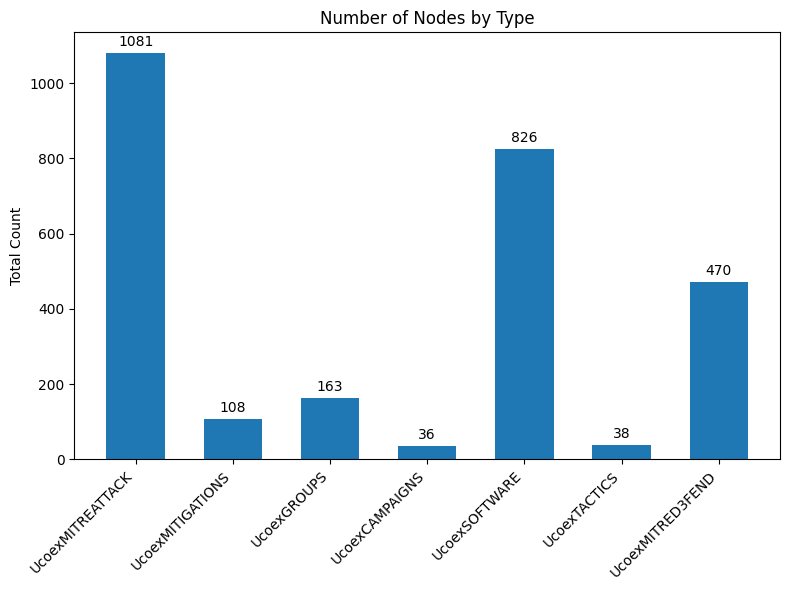

In [30]:
# 1) Define the labels you want to count
labels = [
    "UcoexMITREATTACK",
    "UcoexMITIGATIONS",
    "UcoexGROUPS",
    "UcoexCAMPAIGNS",
    "UcoexSOFTWARE",
    "UcoexTACTICS",
    "UcoexMITRED3FEND"
]

# 2) Query Neo4j for each count
counts = []
for lbl in labels:
    q = f"""
    MATCH (n:{lbl})
    RETURN count(n) AS node_count
    """
    recs = run_query(q, parameters={})
    counts.append(recs[0]["node_count"])

# 3) Plot them in one bar chart
plt.figure(figsize=(8, 6))
plt.bar(labels, counts, width=0.6)           # default colors
plt.ylabel("Total Count")
plt.title("Number of Nodes by Type")

# 4) Annotate each bar with its value
for i, c in enumerate(counts):
    plt.text(i, c + max(counts)*0.01, str(c), ha="center", va="bottom")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

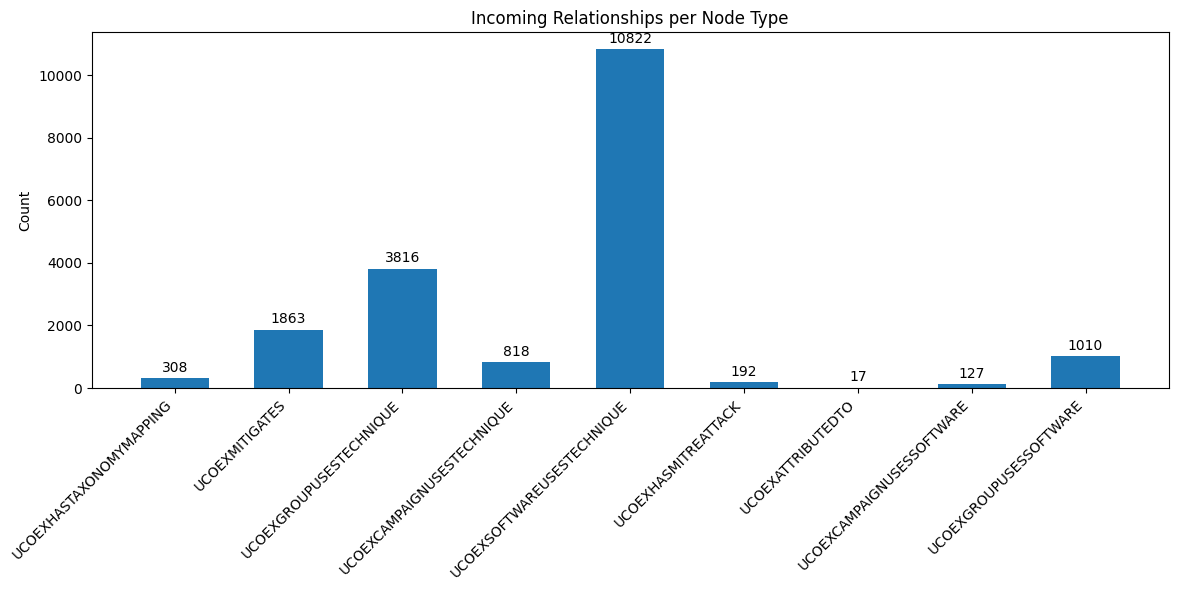

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

labels = [
    "UcoexMITREATTACK",
    "UcoexMITIGATIONS",
    "UcoexGROUPS",
    "UcoexCAMPAIGNS",
    "UcoexSOFTWARE",
    "UcoexTACTICS",
]

records = []
for lbl in labels:
    q = f"""
    MATCH (n:{lbl})<-[r]-()
    RETURN
      "{lbl}"            AS NodeType,
      type(r)            AS IncomingRelationship,
      count(r)           AS Count
    """
    recs = run_query(q, parameters={})
    # recs will be like [{'NodeType': 'UcoexMITREATTACK', 'IncomingRelationship': 'USES', 'Count': 42}, …]
    records.extend(recs)

# Build DataFrame
df = pd.DataFrame(records)


# Prepare for plotting
df['Label'] = df['IncomingRelationship']

# Plot
plt.figure(figsize=(12, 6))
plt.bar(df['Label'], df['Count'], width=0.6)
plt.ylabel("Count")
plt.title("Incoming Relationships per Node Type")
for i, val in enumerate(df['Count']):
    plt.text(i, val + max(df['Count'])*0.01, str(val), ha='center', va='bottom')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [32]:
query = """
MATCH (c:UcoexMITREATTACK)
RETURN count(c) AS attack
"""
params = {}

records = run_query(query, parameters=params)

count = records[0]['attack']

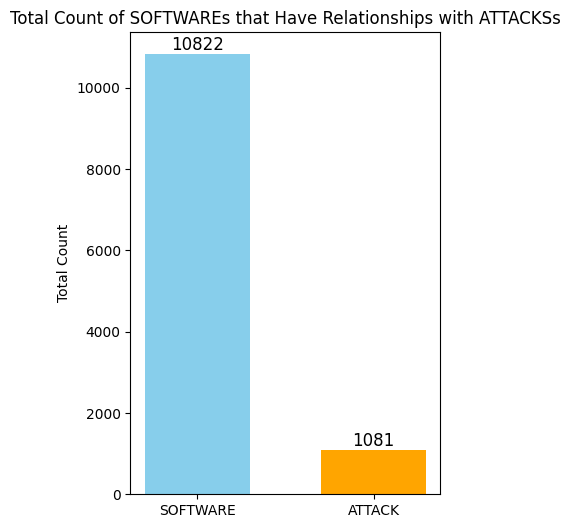

In [33]:
# Total Count of CVEs that have relationships with CPE
query = """
MATCH (c:UcoexMITREATTACK)<-[r]-(t:UcoexSOFTWARE)
RETURN count(t) AS SOFTWARES
"""
params = {}

records = run_query(query, parameters=params)

ATTACK_COUNT = records[0]['SOFTWARES']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['SOFTWARE', 'ATTACK'], [ATTACK_COUNT, count], color=['skyblue', 'orange'], width=0.6)
plt.ylabel('Total Count')
plt.title('Total Count of SOFTWAREs that Have Relationships with ATTACKSs')
plt.text(0, ATTACK_COUNT + 5, str(ATTACK_COUNT), ha='center', va='bottom', fontsize=12)
plt.text(1, count + 5, str(count), ha='center', va='bottom', fontsize=12)
plt.show()

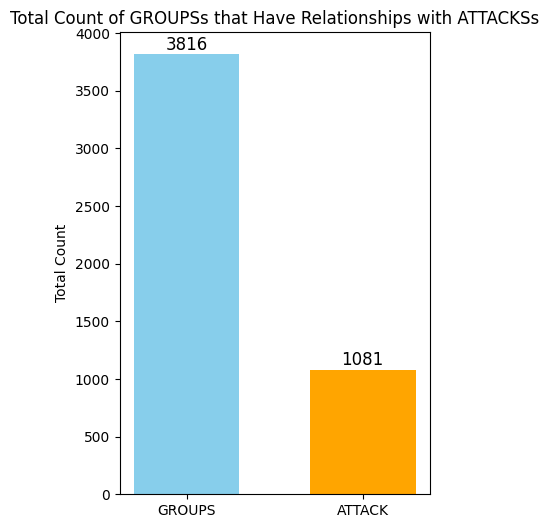

In [34]:
# Total Count of CVEs that have relationships with CPE
query = """
MATCH (c:UcoexMITREATTACK)<-[r]-(t:UcoexGROUPS)
RETURN count(t) AS GROUPS
"""
params = {}

records = run_query(query, parameters=params)

ATTACK_COUNT = records[0]['GROUPS']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['GROUPS', 'ATTACK'], [ATTACK_COUNT, count], color=['skyblue', 'orange'], width=0.6)
plt.ylabel('Total Count')
plt.title('Total Count of GROUPSs that Have Relationships with ATTACKSs')
plt.text(0, ATTACK_COUNT + 5, str(ATTACK_COUNT), ha='center', va='bottom', fontsize=12)
plt.text(1, count + 5, str(count), ha='center', va='bottom', fontsize=12)
plt.show()

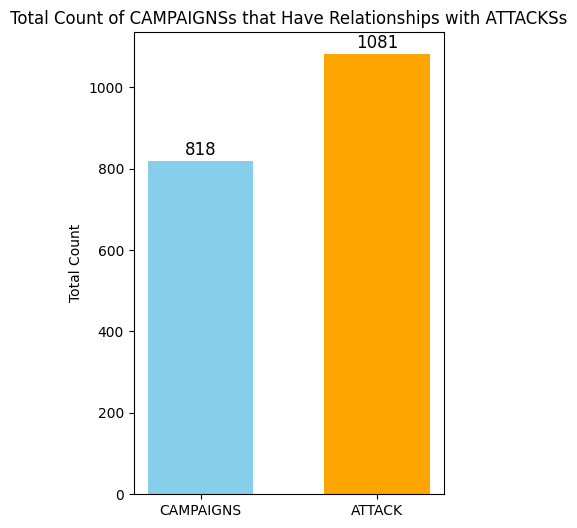

In [35]:
# Total Count of CVEs that have relationships with CPE
query = """
MATCH (c:UcoexMITREATTACK)<-[r]-(t:UcoexCAMPAIGNS)
RETURN count(t) AS CAMPAIGNS
"""
params = {}

records = run_query(query, parameters=params)

ATTACK_COUNT = records[0]['CAMPAIGNS']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['CAMPAIGNS', 'ATTACK'], [ATTACK_COUNT, count], color=['skyblue', 'orange'], width=0.6)
plt.ylabel('Total Count')
plt.title('Total Count of CAMPAIGNSs that Have Relationships with ATTACKSs')
plt.text(0, ATTACK_COUNT + 5, str(ATTACK_COUNT), ha='center', va='bottom', fontsize=12)
plt.text(1, count + 5, str(count), ha='center', va='bottom', fontsize=12)
plt.show()

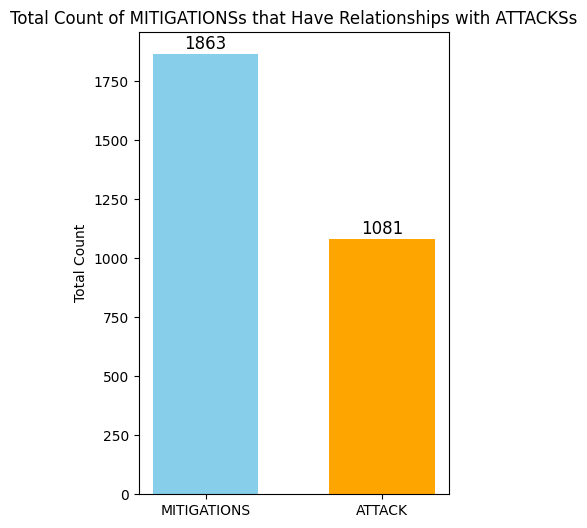

In [36]:
# Total Count of CVEs that have relationships with CPE
query = """
MATCH (c:UcoexMITREATTACK)<-[r]-(t:UcoexMITIGATIONS)
RETURN count(t) AS MITIGATIONS
"""
params = {}

records = run_query(query, parameters=params)

ATTACK_COUNT = records[0]['MITIGATIONS']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['MITIGATIONS', 'ATTACK'], [ATTACK_COUNT, count], color=['skyblue', 'orange'], width=0.6)
plt.ylabel('Total Count')
plt.title('Total Count of MITIGATIONSs that Have Relationships with ATTACKSs')
plt.text(0, ATTACK_COUNT + 5, str(ATTACK_COUNT), ha='center', va='bottom', fontsize=12)
plt.text(1, count + 5, str(count), ha='center', va='bottom', fontsize=12)
plt.show()

In [37]:
query = """
MATCH (c:UcoexGROUPS)
RETURN count(c) AS groups
"""
params = {}

records = run_query(query, parameters=params)

count2 = records[0]['groups']

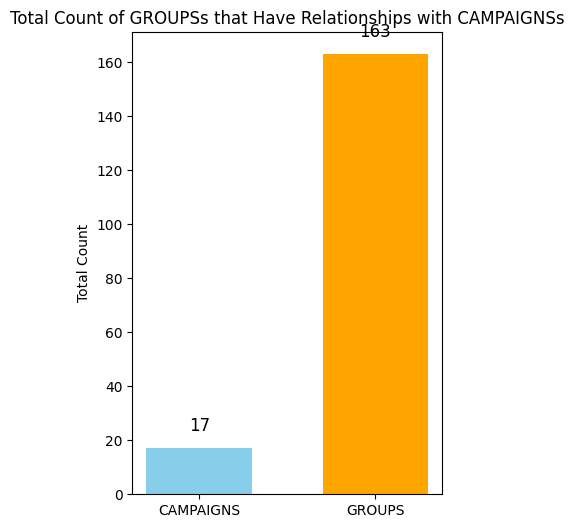

In [38]:
# Total Count of CVEs that have relationships with CPE
query = """
MATCH (c:UcoexGROUPS)<-[r]-(t:UcoexCAMPAIGNS)
RETURN count(t) AS CAMPAIGNS
"""
params = {}

records = run_query(query, parameters=params)

ATTACK_COUNT = records[0]['CAMPAIGNS']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['CAMPAIGNS', 'GROUPS'], [ATTACK_COUNT, count2], color=['skyblue', 'orange'], width=0.6)
plt.ylabel('Total Count')
plt.title('Total Count of GROUPSs that Have Relationships with CAMPAIGNSs')
plt.text(0, ATTACK_COUNT + 5, str(ATTACK_COUNT), ha='center', va='bottom', fontsize=12)
plt.text(1, count2 + 5, str(count2), ha='center', va='bottom', fontsize=12)
plt.show()

This query looks for all paths of length 1 to 4 between nodes with the UcoexMITREATTACK label and nodes with the UcoexMITRED3FEND label.

In [39]:
query = """
MATCH p = (n:UcoexMITREATTACK)-[*1..4]-(m:UcoexMITRED3FEND)
RETURN count(id(m)) AS numOfPaths, count(DISTINCT id(m)) AS numOfAttackPaths
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,numOfPaths,numOfAttackPaths
0,1530631,192


This query looks for any direct relationship (of any type) between nodes labeled UcoexMITREATTACK and nodes labeled UcoexCAPEC

In [40]:
query = """
MATCH p = (n:UcoexMITREATTACK)-[]-(m:UcoexCAPEC)
RETURN count(m) AS numOfPaths, count(DISTINCT m) AS numOfCAPEC
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,numOfPaths,numOfCAPEC
0,308,207


This query looks for any direct relationship (of any type) between nodes labeled UcoexMITREATTACK and nodes labeled UcoexMITRED3FEND

In [41]:
query = """
MATCH p = (n:UcoexMITREATTACK)-[]-(m:UcoexMITRED3FEND)
RETURN count(m) AS numOfPaths, count(DISTINCT m) AS numOfD3FEND
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,numOfPaths,numOfD3FEND
0,192,192
